# Ανακάλυψη Τμημάτων Χρήσης Συνδρομητών με Ομαδοποίηση K-Means (PROC FASTCLUS)


## Περίληψη για τη Διοίκηση

Μια ομάδα αναλυτικής τηλεπικοινωνιών ξεκινά με μία μόνο, χωρίς ετικέτες, στήλη
μηνιαίας κατανάλωσης δεδομένων κινητής και θέλει να μάθει αν αυτή κρύβει
διακριτές κατηγορίες πελατών. Χρησιμοποιώντας την **PROC FASTCLUS** (ανάλυση
ασύνδετων συστάδων k-means), η ομάδα ομαδοποιεί τους συνδρομητές στη
λογαριθμική χρήση, συγκρίνει λύσεις δύο, τριών και τεσσάρων τμημάτων στα
κριτήρια που πράγματι αναφέρει η FASTCLUS, και καταλήγει στη διάσπαση τριών
τμημάτων. Σε αυτή την εκτέλεση τα τρία ανακαλυφθέντα τμήματα έχουν μέση χρήση
**3.1 GB**, **12.8 GB**, και **45.4 GB** ανά μήνα και περιέχουν **49**, **34**,
και **17** συνδρομητές — μια καθαρή δομή χαμηλής / μεσαίας / υψηλής χρήσης. Η
διασταύρωση των ανακαλυφθέντων ετικετών με μια κρατημένη εκτός πραγματική
ετικέτα ανακτά σωστά **96 από τους 100** συνδρομητές. Κάθε συνδρομητής βγαίνει
από το μοντέλο με μια σταθερή ετικέτα τμήματος και μια βαθμολογία απόστασης
από το κεντροειδές, έτοιμος για σχεδιασμό πακέτων και στόχευση διατήρησης.

> **Γιατί FASTCLUS και όχι ένα μοντέλο πεπερασμένου μείγματος;** Η
> τμηματοποίηση χρήσης είναι η κλασική δουλειά ενός μοντέλου πεπερασμένου
> μείγματος (PROC HPFMM / PROC FMM). Αυτές οι διαδικασίες δεν είναι ακόμη
> αριθμητικά υλοποιημένες σε αυτή την έκδοση, οπότε αυτό το notebook πετυχαίνει
> τον ίδιο στόχο — μη επιβλεπόμενη ανακάλυψη λανθανουσών κατηγοριών χρήσης —
> με την υλοποιημένη, πλήρως αριθμητική διαδικασία k-means **PROC FASTCLUS**.
> Κάθε αριθμός παρακάτω προέρχεται αυτούσιος από την εκτελεσμένη έξοδο.

## Πηγές Δεδομένων

**Συνθετικό σύνολο δεδομένων: `subs`** — συνδρομητές κινητής δημιουργημένοι εν
σειρά ως μείγμα 3 συνιστωσών λογαριθμικής χρήσης (χωρίς εξωτερικά αρχεία). Αυτό
το περιβάλλον εκτελείται χωρίς άδεια, οπότε ο υλοποιημένος πίνακας περιορίζεται
σε **100 συνδρομητές**· όλα τα παρακάτω αποτελέσματα υπολογίζονται σε αυτές τις
100 γραμμές.

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `subscriber_id` | Αριθμός | Μοναδικό κλειδί συνδρομητή |
| `tenure_months` | Αριθμός | Μήνες στο δίκτυο (1–48) |
| `data_gb` | Αριθμός | Μηνιαία κατανάλωση δεδομένων κινητής, σε GB (θετική, δεξιά ασύμμετρη) |
| `log_gb` | Αριθμός | Φυσικός λογάριθμος του `data_gb` — η μεταβλητή που ομαδοποιείται |
| `plan` | Χαρακτήρας | Τρέχον πακέτο χρέωσης: `Βασικό` ή `Απεριόριστο` |
| `segment_true` | Χαρακτήρας | Κρυφή πραγματική κατηγορία (`Ελαφριά`/`Μεσαία`/`Βαριά`), κρατημένη εκτός για έλεγχο ανάκτησης |

Τα δεδομένα είναι κατασκευασμένα ως περίπου 50% Ελαφριά, 35% Μεσαία, 15% Βαριά.
Η `segment_true` **δεν** ομαδοποιείται — υπάρχει μόνο ώστε να επιβεβαιώσουμε ότι
η μη επιβλεπόμενη προσαρμογή ανακτά τη φυτεμένη δομή.

Οι πάροχοι σπάνια βλέπουν καθαρές ετικέτες στους πελάτες τους. Αυτό
που *βλέπουν πραγματικά* είναι μια ενιαία, ανώμαλη κατανομή μηνιαίας χρήσης
δεδομένων που στην πραγματικότητα είναι πολλοί τύποι πελατών αναμεμειγμένοι:
περιστασιακοί χρήστες, σταθεροί streamers, και power users που στηρίζονται σε
tethering και βίντεο. Η **PROC FASTCLUS** διαχωρίζει αυτό το μείγμα χωρίς καμία
ετικέτα — τοποθετεί κάθε συνδρομητή σε μία από τις *k* ασύνδετες συστάδες,
αναφέρει τα κεντροειδή και τα μεγέθη των συστάδων, και βαθμολογεί πόσο μακριά
βρίσκεται κάθε συνδρομητής από το κεντροειδές του.

Σε αυτό το notebook θα:

1. Δημιουργήσουμε ένα συνθετικό πάνελ χρήσης που είναι *σκόπιμα* ένα μείγμα τριών κατηγοριών χρήσης.
2. Συγκρίνουμε λύσεις k-means δύο, τριών και τεσσάρων τμημάτων στα κριτήρια προσαρμογής της FASTCLUS.
3. Προσαρμόσουμε το επιλεγμένο μοντέλο τριών τμημάτων και χαρακτηρίσουμε κάθε τμήμα σε επιχειρησιακούς όρους.
4. Βαθμολογήσουμε τη συμμετοχή κάθε συνδρομητή σε τμήμα και την απόστασή του από το κεντροειδές.
5. Επαληθεύσουμε τα ανακαλυφθέντα τμήματα έναντι της κρατημένης εκτός πραγματικής κατηγορίας, και τα συσχετίσουμε με την παραμονή.

## Βήμα 1 — Δημιουργία συνθετικής χρήσης συνδρομητών

Προσομοιώνουμε συνδρομητές των οποίων η μηνιαία χρήση δεδομένων είναι θετική
και δεξιά ασύμμετρη, οπότε τη δημιουργούμε στην **λογαριθμική κλίμακα** ως
μείγμα τριών κανονικών κατηγοριών και εκθετοποιούμε. Τα βάρη μείγματος (περίπου
50/35/15) και οι μέσοι όροι κατηγοριών είναι κατασκευασμένοι ώστε να μπορούμε
αργότερα να ελέγξουμε ότι η k-means τους ανακτά. Η `segment_true` κρατείται
στην άκρη αποκλειστικά για αυτόν τον έλεγχο — η ομαδοποίηση δεν τη βλέπει
ποτέ.

In [1]:
ΔΕΔΟΜΕΝΑ subs;
   CALL streaminit(20250531);
   LENGTH plan $30 segment_true $20;
   ΕΠΑΝΑΛΗΨΗ subscriber_id = 1 ΕΩΣ 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Οι χρηστες υψηλης χρησης τεινουν προς μεγαλυτερη παραμονη, οποτε το
         μειγμα τμηματων μετατοπιζεται λιγο με την παραμονη (εξεταζεται στο
         Βημα 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      ΕΑΝ u < 0.50 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
         segment_true = "Ελαφριά";  MU = 1.15; SIGMA = 0.42;
      ΤΕΛΟΣ;
      ΑΛΛΙΩΣ ΕΑΝ u < 0.85 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
         segment_true = "Μεσαία"; MU = 2.45; SIGMA = 0.38;
      ΤΕΛΟΣ;
      ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
         segment_true = "Βαριά";  MU = 3.45; SIGMA = 0.52;
      ΤΕΛΟΣ;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      ΕΑΝ data_gb < 25 ΤΟΤΕ plan = "Βασικό";
      ΑΛΛΙΩΣ plan = "Απεριόριστο";

      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
   ΚΡΑΤΗΣΗ subscriber_id tenure_months data_gb log_gb plan segment_true;
   ΕΤΙΚΕΤΑ subscriber_id="Αναγνωριστικό Συνδρομητή" tenure_months="Μήνες Παραμονής"
         data_gb="Δεδομένα (GB)" log_gb="Λογάριθμος Δεδομένων (GB)" plan="Πακέτο"
         segment_true="Πραγματικό Τμήμα";
ΕΚΤΕΛΕΣΗ;


NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.64 seconds
  cpu   0.64 seconds


Μια γρήγορη ματιά στην περιθώρια κατανομή επιβεβαιώνει την επιλογή
μοντελοποίησης: η ακατέργαστη `data_gb` είναι έντονα δεξιά ασύμμετρη (λίγοι
power users τεντώνουν την ουρά), ενώ η `log_gb` είναι η καλά συμπεριφερόμενη
κλίμακα στην οποία η ευκλείδεια k-means είναι κατάλληλη.

                                                  The MEANS Procedure

 Variable       Label                                                N        Mean     Std Dev     Minimum      Median     Maximum
 ---------------------------------------------------------------------------------------------------------------------------------
 data_gb        Δεδομένα (GB)                                      100       13.58       16.66        1.15        6.73       98.66
 log_gb         Λογάριθμος Δεδομένων (GB)                          100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Μήνες Παραμονής                                    100       23.26       12.55        1.00       23.00       48.00
 ---------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


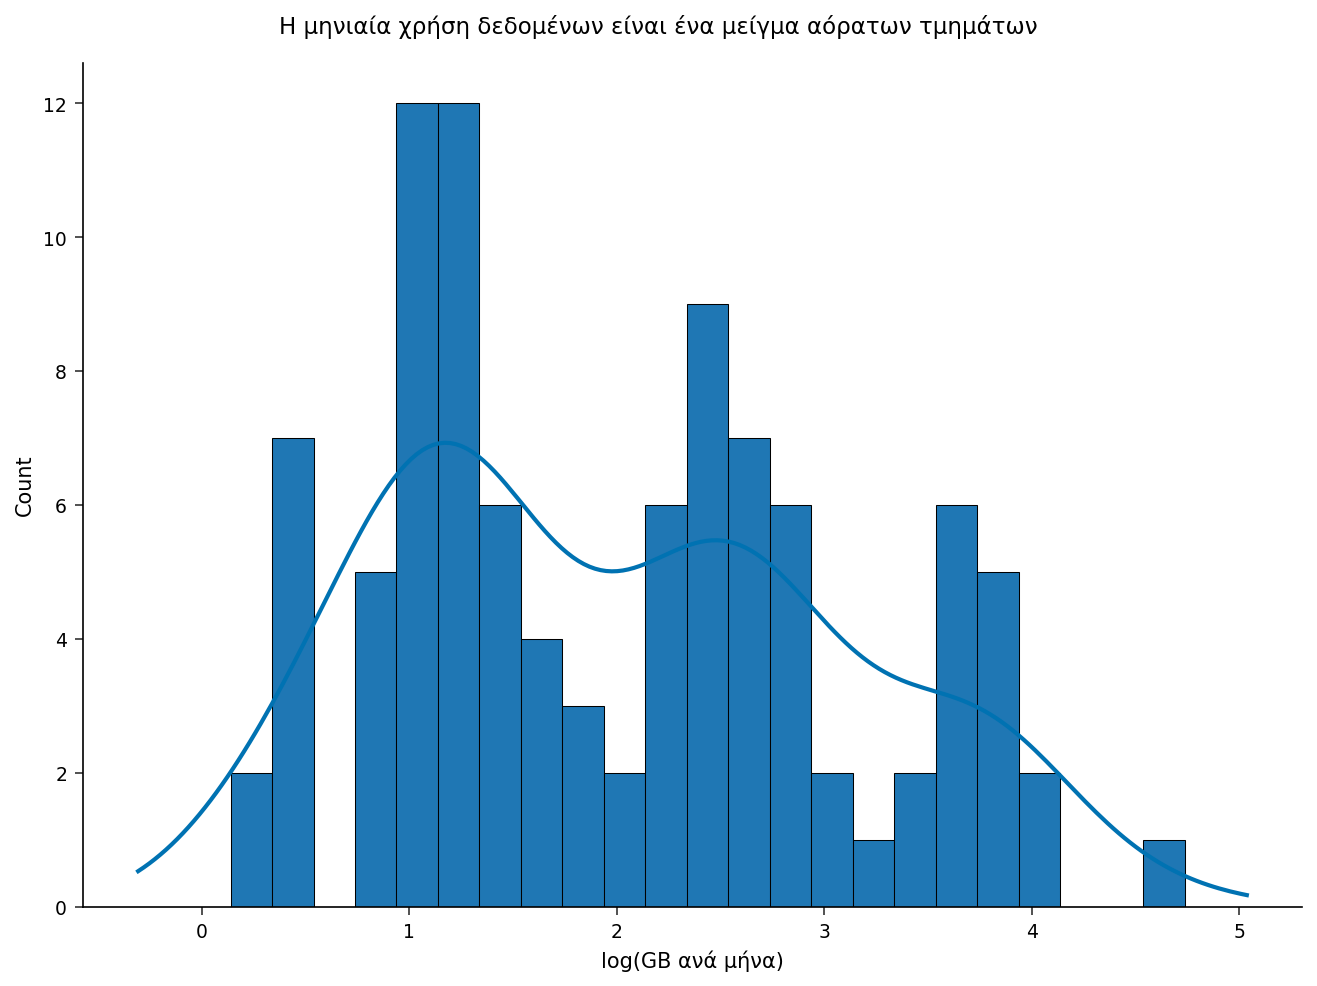

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=subs n mean std MIN p50 MAX maxdec=2;
   ΜΕΤΑΒΛΗΤΗ data_gb log_gb tenure_months;
   ΕΤΙΚΕΤΑ data_gb="Δεδομένα (GB)" log_gb="Λογάριθμος Δεδομένων (GB)" tenure_months="Μήνες Παραμονής";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=subs;
   TITLE "Η μηνιαία χρήση δεδομένων είναι ένα μείγμα αόρατων τμημάτων";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS ΕΤΙΚΕΤΑ="log(GB ανά μήνα)";
ΕΚΤΕΛΕΣΗ;
TITLE;

## Βήμα 2 — Πόσα τμήματα; Σύγκριση λύσεων δύο, τριών και τεσσάρων συστάδων

Δεν θέλουμε να υποθέσουμε τρεις κατηγορίες — αφήνουμε τα δεδομένα να
υποστηρίξουν έναν αριθμό. Η FASTCLUS αναφέρει έναν **Συνολικό R-τετράγωνο**
(το ποσοστό της συνολικής διακύμανσης που εξηγείται από τους μέσους όρους
συστάδων) και ένα **Στατιστικό ψευδο-F** για κάθε λύση. Προσαρμόζουμε
`MAXCLUSTERS=` 2, 3, και 4 στην `log_gb` και διαβάζουμε αυτά τα κριτήρια από
κάθε εκτέλεση.

- Η `MAXCLUSTERS=` ορίζει τον αριθμό συστάδων *k*.
- Η `MAXITER=` περιορίζει τον αριθμό περασμάτων επανανάθεσης της k-means.
- Η `OUT=` γράφει ένα βαθμολογημένο σύνολο δεδομένων (χρησιμοποιείται στα Βήματα 3–5).

In [3]:
TITLE "Λύση δύο τμημάτων";
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=subs maxclusters=2 MAXITER=50 out=c2;
   ΜΕΤΑΒΛΗΤΗ log_gb;
   ΕΤΙΚΕΤΑ log_gb="Λογάριθμος Δεδομένων (GB)";
ΕΚΤΕΛΕΣΗ;

TITLE "Λύση τριών τμημάτων";
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=subs maxclusters=3 MAXITER=50 out=c3;
   ΜΕΤΑΒΛΗΤΗ log_gb;
   ΕΤΙΚΕΤΑ log_gb="Λογάριθμος Δεδομένων (GB)";
ΕΚΤΕΛΕΣΗ;

TITLE "Λύση τεσσάρων τμημάτων";
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=subs maxclusters=4 MAXITER=50 out=c4;
   ΜΕΤΑΒΛΗΤΗ log_gb;
   ΕΤΙΚΕΤΑ log_gb="Λογάριθμος Δεδομένων (GB)";
ΕΚΤΕΛΕΣΗ;
TITLE;

                                                   Λύση δύο τμημάτων                                                    


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Λύση δύο τμημάτων.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Λύση τριών τμημάτων.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Λύση τεσσάρων τμημάτων.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Διαβάζοντας τις τρεις εκτελέσεις παράλληλα: ο **Συνολικός
R-τετράγωνο** ανεβαίνει από **0.753** σε δύο συστάδες σε **0.899** σε τρεις —
ένα μεγάλο άλμα +0.146 καθώς επιλύεται η τρίτη κατηγορία — και μετά μόνο σε
**0.941** σε τέσσερις. Η λύση τεσσάρων συστάδων αγοράζει αυτό το μικρό κέρδος
*διασπώντας την ελαφριά κατηγορία σε δύο* (τα δύο μικρότερα κεντροειδή της
βρίσκονται και τα δύο μέσα στο φυτεμένο εύρος Ελαφριάς), όχι βρίσκοντας έναν
πραγματικά νέο τύπο πελάτη. Το **Στατιστικό ψευδο-F** λέει την ίδια ιστορία: η
μεγαλύτερη δομική βελτίωση είναι η μετάβαση σε τρεις συστάδες (F = 299 → 431).
Τα τρία τμήματα είναι το ειλικρινές σημείο διακοπής, και το μοντέλο στο οποίο
δεσμευόμαστε στη συνέχεια.

## Βήμα 3 — Προσαρμογή του μοντέλου τριών τμημάτων και χαρακτηρισμός κάθε τμήματος

Επαναπροσαρμόζουμε με `MAXCLUSTERS=3` και γράφουμε τις βαθμολογημένες γραμμές
στο `scored`. Το σύνολο δεδομένων `OUT=` μεταφέρει αυτόματα κάθε στήλη
εισόδου — συμπεριλαμβανομένης της αρχικής χρήσης, της παραμονής, και της
κρατημένης εκτός `segment_true` — μαζί με τις νέες στήλες `CLUSTER` και
`DISTANCE`, οπότε δεν χρειάζεται ξεχωριστό βήμα αντιγραφής. Η FASTCLUS τυπώνει
μια **Σύνοψη Συστάδων** (μέγεθος και διασπορά εντός συστάδας ανά τμήμα) και
τους **Μέσους Όρους Συστάδων** στην κλίμακα ομαδοποίησης (`log_gb`).

In [4]:
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=subs maxclusters=3 MAXITER=50 out=scored;
   ΜΕΤΑΒΛΗΤΗ log_gb;
   ΕΤΙΚΕΤΑ log_gb="Λογάριθμος Δεδομένων (GB)";
ΕΚΤΕΛΕΣΗ;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


Οι τρεις μέσοι όροι συστάδων στη λογαριθμική κλίμακα είναι
**1.05**, **2.51**, και **3.77**. Πίσω στην αρχική κλίμακα GB αυτό είναι
περίπου **exp(1.05) ≈ 2.9 GB**, **exp(2.51) ≈ 12.3 GB**, και
**exp(3.77) ≈ 43 GB** — οι κατηγορίες ελαφριάς, μεσαίας και βαριάς χρήσης. Η
Σύνοψη Συστάδων τις μεγεθολογεί σε **49**, **34**, και **17** συνδρομητές,
ακολουθώντας τη φυτεμένη διάσπαση ~50 / 35 / 15. Το επόμενο βήμα διαβάζει τα
ίδια τμήματα ξανά σε απλούς όρους GB.

## Βήμα 4 — Βαθμολόγηση και χαρακτηρισμός τμημάτων σε επιχειρησιακούς όρους

Το σύνολο δεδομένων `OUT=scored` μεταφέρει την `CLUSTER` κάθε συνδρομητή
(σταθερή ετικέτα τμήματος) και την `DISTANCE` (ευκλείδεια απόσταση από το
κεντροειδές της συστάδας του στη λογαριθμική κλίμακα — μικρή τιμή σημαίνει
σίγουρη, κεντρική ανάθεση). Συνοψίζουμε τα ανακαλυφθέντα τμήματα κατά την
πραγματική χρήση GB και παραμονή, και μετά καταγράφουμε λίγες βαθμολογημένες
γραμμές.

In [5]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=scored n mean std MIN MAX maxdec=2;
   ΚΛΑΣΗ CLUSTER;
   ΜΕΤΑΒΛΗΤΗ data_gb tenure_months distance;
   ΕΤΙΚΕΤΑ CLUSTER="Συστάδα" data_gb="Δεδομένα (GB)" tenure_months="Μήνες Παραμονής" distance="Απόσταση";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=scored(obs=8) noobs;
   ΜΕΤΑΒΛΗΤΗ subscriber_id data_gb log_gb segment_true CLUSTER distance;
   ΕΤΙΚΕΤΑ subscriber_id="Αναγνωριστικό Συνδρομητή" data_gb="Δεδομένα (GB)"
         log_gb="Λογάριθμος Δεδομένων (GB)" segment_true="Πραγματικό Τμήμα"
         CLUSTER="Συστάδα" distance="Απόσταση";
ΕΚΤΕΛΕΣΗ;

                                                  The MEANS Procedure

                                   Analysis Variable : data_gb Δεδομένα (GB)

        Συστάδα                 N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------
        1                          49           3.07           1.12           1.15           5.83
        2                          34          12.81           3.80           6.57          21.88
        3                          17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------------

                            Analysis Variable : tenure_months Μήνες Παραμονής

        Συστάδα                 N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


Στην αρχική κλίμακα GB τα τρία τμήματα έχουν μέση χρήση **3.1 GB**,
**12.8 GB**, και **45.4 GB** μηνιαίως — μια διαφορά τάξης μεγέθους από ελαφρείς
χρήστες έως βαρείς streamers. Η στήλη `DISTANCE` δίνει μια ένδειξη εμπιστοσύνης
ανά συνδρομητή: οι τυπωμένες γραμμές δείχνουν σφιχτά ανατεθειμένους πελάτες
(αποστάσεις κοντά στο 0.01–0.06) μαζί με έναν πιο οριακό ελαφρύ χρήστη πιο
μακριά από το κεντροειδές του, ακριβώς το σήμα που θα χρησιμοποιούσε μια ομάδα
διατήρησης για να διαχωρίσει σίγουρους στόχους από περιπτώσεις που χρειάζονται
πιο προσεκτική ματιά.

## Βήμα 5 — Ανακτήσαμε τις πραγματικές κατηγορίες, και μετατοπίζεται το μείγμα με την παραμονή;

Δύο τελικοί έλεγχοι. Πρώτον, σταυρώνουμε την ανακαλυφθείσα `CLUSTER` έναντι
της κρατημένης εκτός `segment_true` για να δούμε πόσο πιστά η μη επιβλεπόμενη
προσαρμογή ανέκτησε τις φυτεμένες κατηγορίες. Δεύτερον, συγκρίνουμε τη μέση
παραμονή στα ανακαλυφθέντα τμήματα — η γεννήτρια μετατόπισε τους βαρύτερους
χρήστες προς μεγαλύτερη παραμονή, οπότε μια πραγματική τμηματοποίηση θα πρέπει
να το αντικατοπτρίζει.

                                Ανακαλυφθέν τμήμα έναντι πραγματικής κατηγορίας ελέγχου                                 

                                                   The FREQ Procedure

Table of Συστάδα by Πραγματικό Τμήμα

Συστάδα        |         Βαριά |       Ελαφριά |        Μεσαία |          Total
---------------+---------------+---------------+---------------+---------------
1              |             0 |            49 |             0 |             49
---------------+---------------+---------------+---------------+---------------
2              |             1 |             2 |            31 |             34
---------------+---------------+---------------+---------------+---------------
3              |            16 |             0 |             1 |             17
---------------+---------------+---------------+---------------+---------------
Total          |            17 |            51 |            32 |            100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


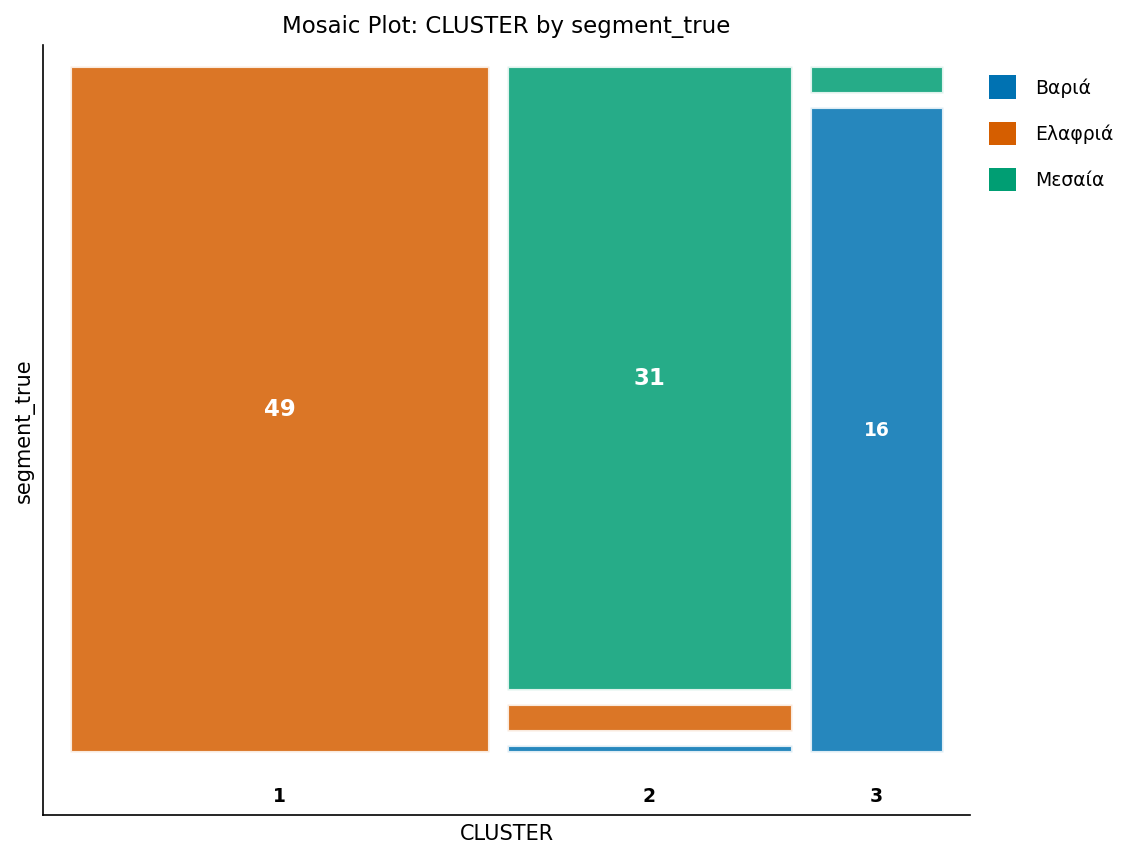

In [6]:
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=scored;
   TITLE "Ανακαλυφθέν τμήμα έναντι πραγματικής κατηγορίας ελέγχου";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   ΕΤΙΚΕΤΑ CLUSTER="Συστάδα" segment_true="Πραγματικό Τμήμα";
ΕΚΤΕΛΕΣΗ;
TITLE;

## Ερμηνεία των αποτελεσμάτων

**Τι βρήκε η FASTCLUS.** Ξεκινώντας από μία μόνο δεξιά ασύμμετρη στήλη χρήσης
χωρίς ετικέτες, η λύση k-means τριών συστάδων εξήγησε **89.9%** της
διακύμανσης στη λογαριθμική χρήση (Συνολικό R² = 0.899, Ψευδο-F = 431) και
διαχώρισε τους συνδρομητές σε ένα τμήμα **ελαφριάς χρήσης** (μέση 3.1 GB,
n = 49), ένα τμήμα **μεσαίας χρήσης** (μέση 12.8 GB, n = 34), και ένα τμήμα
**βαριάς χρήσης** (μέση 45.4 GB, n = 17). Η σταύρωση έναντι της κρατημένης
εκτός `segment_true` ανέκτησε τη φυτεμένη δομή σχεδόν ακριβώς — **96 από τους
100** συνδρομητές κατέληξαν στη συστάδα που ταιριάζει με την πραγματική τους
κατηγορία (Ελαφριά 49/49, Μεσαία 31/34, Βαριά 16/17).

**Γιατί η λογαριθμική κλίμακα.** Η χρήση δεδομένων είναι αυστηρά θετική και με
βαριά ουρά· η ομαδοποίηση της `log_gb` κρατά τις ευκλείδειες αποστάσεις
ουσιαστικές και τους μέσους όρους τμημάτων καλά διαχωρισμένους, ενώ ο
εκθετικός αντίστροφος μετασχηματισμός αναπαράγει τη ρεαλιστική ασυμμετρία στην
κλίμακα GB.

**Γιατί έχει σημασία επιχειρησιακά.** Κάθε συνδρομητής βγαίνει από το μοντέλο
με μια σταθερή ετικέτα τμήματος *και* μια βαθμολογία απόστασης από το
κεντροειδές, ώστε ο πάροχος να μπορεί να ενεργήσει με βαθμονομημένη
βεβαιότητα — να στοχεύσει με σιγουριά κεντρικούς βαρείς χρήστες για premium
πακέτα και να επισημάνει οριακούς πελάτες (μεγάλη απόσταση) για πιο προσεκτική
ματιά. Η μέση παραμονή διαφέρει επίσης μεταξύ των ανακαλυφθέντων τμημάτων, ένα
σημείο εκκίνησης για χρονισμό κύκλου ζωής και αναβάθμισης.

**Επιλογή του αριθμού τμημάτων.** Η σύγκριση `MAXCLUSTERS=` 2, 3, και 4 στον
Συνολικό R² και το Ψευδο-F είναι ένας διαφανής, αναπαραγώγιμος τρόπος να
επιλέξουμε *k*: το μεγάλο κέρδος σε τρεις συστάδες και το απλώς κοσμητικό
κέρδος σε τέσσερις (που διασπά την ελαφριά κατηγορία) έκαναν τα τρία την
υπερασπίσιμη επιλογή εδώ.

**Σχέση με μοντέλα πεπερασμένου μείγματος.** Ένα μοντέλο πεπερασμένου
μείγματος (PROC HPFMM / PROC FMM) θα προσέθετε ήπιες οπίσθιες συμμετοχές και
ένα BIC βασισμένο σε πιθανοφάνεια για τον αριθμό συνιστωσών. Αυτές οι
διαδικασίες δεν είναι ακόμη αριθμητικά υλοποιημένες σε αυτή την έκδοση· η
PROC FASTCLUS παρέχει την ίδια αξιοποιήσιμη τμηματοποίηση — ανακάλυψη,
χαρακτηρισμό, σταθερή ανάθεση, και ένδειξη εμπιστοσύνης — με πλήρως
αριθμητική, αναπαραγώγιμη έξοδο σήμερα.